# RQ1 — Accuracy vs Sustainability Trade-off

              Model          RMSE   R2Score  RuntimeSeconds   MemoryMB  \
0  LinearRegression  4.181665e-14  1.000000        0.270383  13.708529   
1      RandomForest  1.784520e+00  0.988044       32.171805   1.523680   
2           XGBoost  1.137825e+00  0.995139        0.959288   0.252545   
3     NeuralNetwork  2.738924e+00  0.971836        7.010885   1.767707   

   EstimatedCO2  
0      0.002704  
1      0.321718  
2      0.009593  
3      0.070109  


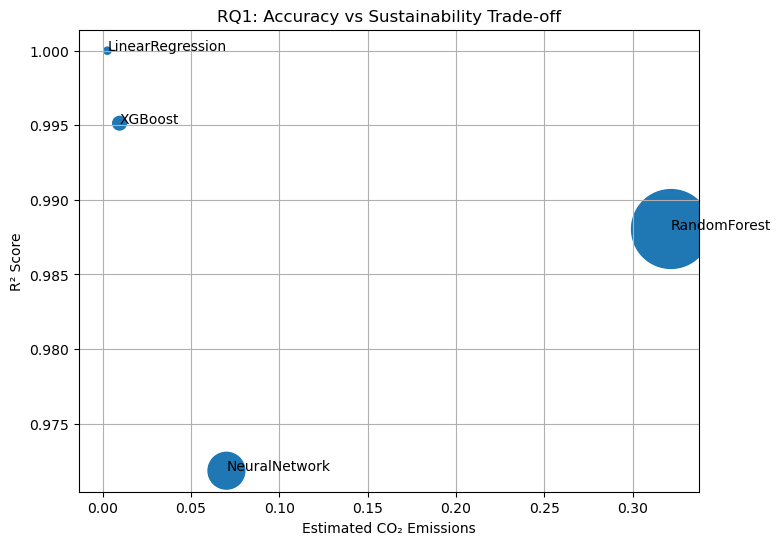

In [5]:
# Install XGBoost (run once)
!pip install xgboost -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import tracemalloc

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor

from xgboost import XGBRegressor

# ==========================
# Load Dataset
# ==========================

df = pd.read_csv("iiot_smart_grid_dataset.csv")

# Remove missing values
df = df.dropna()

# Encode categorical columns
for col in df.select_dtypes(include='object').columns:
    df[col] = LabelEncoder().fit_transform(df[col])

# ==========================
# Features and Target
# ==========================

X = df.drop("Energy_Efficiency_Score", axis=1)
y = df["Energy_Efficiency_Score"]

# ==========================
# Train Test Split
# ==========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ==========================
# Models
# ==========================

models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ),
    "XGBoost": XGBRegressor(
        n_estimators=100,
        random_state=42
    ),
    "NeuralNetwork": MLPRegressor(
        hidden_layer_sizes=(100,),
        max_iter=500,
        random_state=42
    )
}

# ==========================
# Training and Evaluation
# ==========================

results = []

for name, model in models.items():

    tracemalloc.start()

    start = time.time()

    model.fit(X_train, y_train)

    runtime = time.time() - start

    current, peak = tracemalloc.get_traced_memory()

    tracemalloc.stop()

    preds = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, preds))

    r2 = r2_score(y_test, preds)

    estimated_co2 = runtime * 0.01

    results.append([
        name,
        rmse,
        r2,
        runtime,
        peak / (1024 * 1024),
        estimated_co2
    ])

# ==========================
# Results Table
# ==========================

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "RMSE",
        "R2Score",
        "RuntimeSeconds",
        "MemoryMB",
        "EstimatedCO2"
    ]
)

results_df.to_csv(
    "RQ1_results_table.csv",
    index=False
)

print(results_df)

# ==========================
# Publication Figure
# ==========================

plt.figure(figsize=(8,6))

sizes = results_df["RuntimeSeconds"] * 100

plt.scatter(
    results_df["EstimatedCO2"],
    results_df["R2Score"],
    s=sizes
)

for i, row in results_df.iterrows():

    plt.annotate(
        row["Model"],
        (
            row["EstimatedCO2"],
            row["R2Score"]
        )
    )

plt.xlabel("Estimated CO₂ Emissions")

plt.ylabel("R² Score")

plt.title("RQ1: Accuracy vs Sustainability Trade-off")

plt.grid(True)

plt.savefig(
    "RQ1_accuracy_vs_sustainability.pdf",
    bbox_inches="tight"
)

plt.show()